# (26) Kyoto — save 16x16

**Motivation**: $16 \times 16$, low contrast removed (bottom 1%). <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights

import scipy.io as sio

from utils.imgproc import (
    do_process, xtract_patches,
    do_fft, compute_fftfreq,
    EyeDataset,
)


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Load KYOTO images

In [3]:
root = 'Datasets/Kyoto'
root = add_home(root)

raw_dir = pjoin(root, 'raw')
files = sorted(os.listdir(raw_dir), key=alphanum_sort_key)
len(files)

62

### get color imgs

In [4]:
imgs_color = collections.defaultdict(list)

for f in files:
    data_dict = sio.loadmat(pjoin(raw_dir, f))
    img_dim = np.asarray(data_dict['OL']).shape

    img = np.zeros([img_dim[0],img_dim[1],3])
    img[:,:,0] = np.asarray(data_dict['OL'])
    img[:,:,1] = np.asarray(data_dict['OM'])
    img[:,:,2] = np.asarray(data_dict['OS'])

    imgs_color[img_dim].append(img)

imgs_color = {k: np.stack(v) for k, v in imgs_color.items()}
print({k: v.shape for k, v in imgs_color.items()})

{(500, 640): (50, 500, 640, 3), (640, 500): (12, 640, 500, 3)}

In [5]:
x2p = imgs_color[(500, 640)][14]
x2p_bw = x2p.mean(-1)

x2p.shape, x2p_bw.shape

((500, 640, 3), (500, 640))

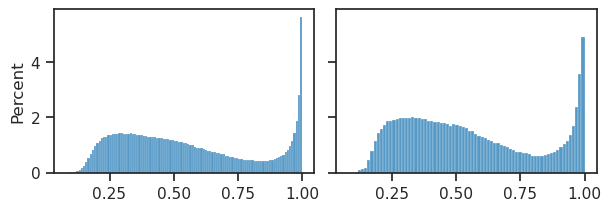

In [6]:
fig, axes = create_figure(1, 2, sharex='all', sharey='all')

sns.histplot(x2p.ravel(), stat='percent', ax=axes[0])
sns.histplot(x2p_bw.ravel(), stat='percent', ax=axes[1])
plt.show()

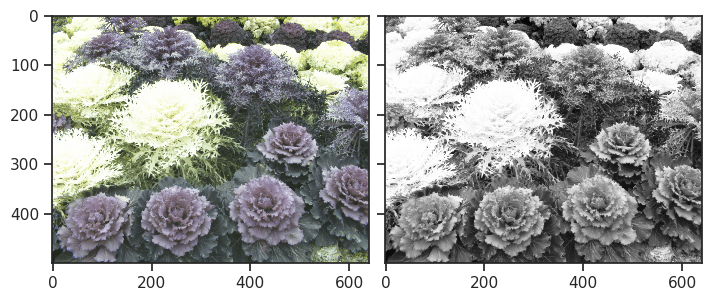

In [7]:
fig, axes = create_figure(1, 2, (7, 3), sharex='all', sharey='all')

axes[0].imshow(x2p)
axes[1].imshow(x2p_bw, cmap='Greys_r')
plt.show()

### get black & white images

In [8]:
common_dim = max(
    {k: len(v) for k, v in imgs_color.items()},
    key=lambda tup: tup[1],
)
common_dim = min(common_dim)
common_dim

500

In [9]:
imgs_bw = np.concatenate([
    v[:, :common_dim, :common_dim].mean(-1)
    for v in imgs_color.values()
])
imgs_bw.shape

(62, 500, 500)

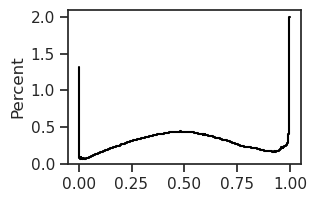

In [10]:
histplot(imgs_bw.ravel(), stat='percent', color='k');

### Save color and b&w images

In [11]:
save_dir = pjoin(root, 'processed')
os.makedirs(save_dir, exist_ok=True)
os.listdir(save_dir)

['kyoto_bnw.npy', 'kyoto_color.npy']

In [12]:
save = {
    'kyoto_color': imgs_color,
    'kyoto_bnw': imgs_bw,
}
for name, obj in save.items():
    save_obj(
        obj=obj,
        file_name=name,
        save_dir=save_dir,
        verbose=True,
        mode='npy',
    )

[PROGRESS] 'kyoto_color.npy' saved at
/home/hadi/Datasets/Kyoto/processed

[PROGRESS] 'kyoto_bnw.npy' saved at
/home/hadi/Datasets/Kyoto/processed

## Xtract patches: $16 \times 16$

In [13]:
npix = 16
crop_size = 2

imgs_tensor = {
    k: torch.from_numpy(v.mean(-1)).to(device=device).unsqueeze(1)
    for k, v in imgs_color.items()
}

patches = {
    k: xtract_patches(v, npix=npix + 2 * crop_size)
    for k, v in imgs_tensor.items()
}
patches = torch.cat(list(patches.values()))
patches = patches.float()

print(patches.shape, patches.dtype)

torch.Size([62, 800, 1, 20, 20])
torch.float32

### Process

In [14]:
x_wt, x_wt_cn, x_wt_cn_zs = do_process(patches, crop_size=crop_size)
x = patches[..., crop_size:-crop_size, crop_size:-crop_size]

patches.shape, x.shape, x_wt_cn_zs.shape

(torch.Size([62, 800, 1, 20, 20]),
 torch.Size([62, 800, 1, 16, 16]),
 torch.Size([62, 800, 1, 16, 16]))

### Identify low contrast patches

Bottom 1%

In [17]:
q = 0.01

vars = np.var(tonp(x), axis=(-1, -2))
vars[vars == 0] = 1e-10  # prevent div by zero warning

log_vars = np.log(vars.ravel())
thres = np.quantile(log_vars, q)
accept = log_vars > thres

msg = f"# removed: {(~accept).sum()} ——— # final: {accept.sum()}"
print(msg)

# removed: 496 ——— # final: 49104

### Remove low contrast patches

In [18]:
x, x_wt, x_wt_cn, x_wt_cn_zs = map(
    lambda a: flatten_np(a, end_dim=1)[accept],
    [x, x_wt, x_wt_cn, x_wt_cn_zs],
)
x_wt_cn_zs.shape

torch.Size([49104, 1, 16, 16])

In [19]:
ncols = 32
rng = get_rng(0)
ids = rng.choice(range(len(x)), size=ncols, replace=False)

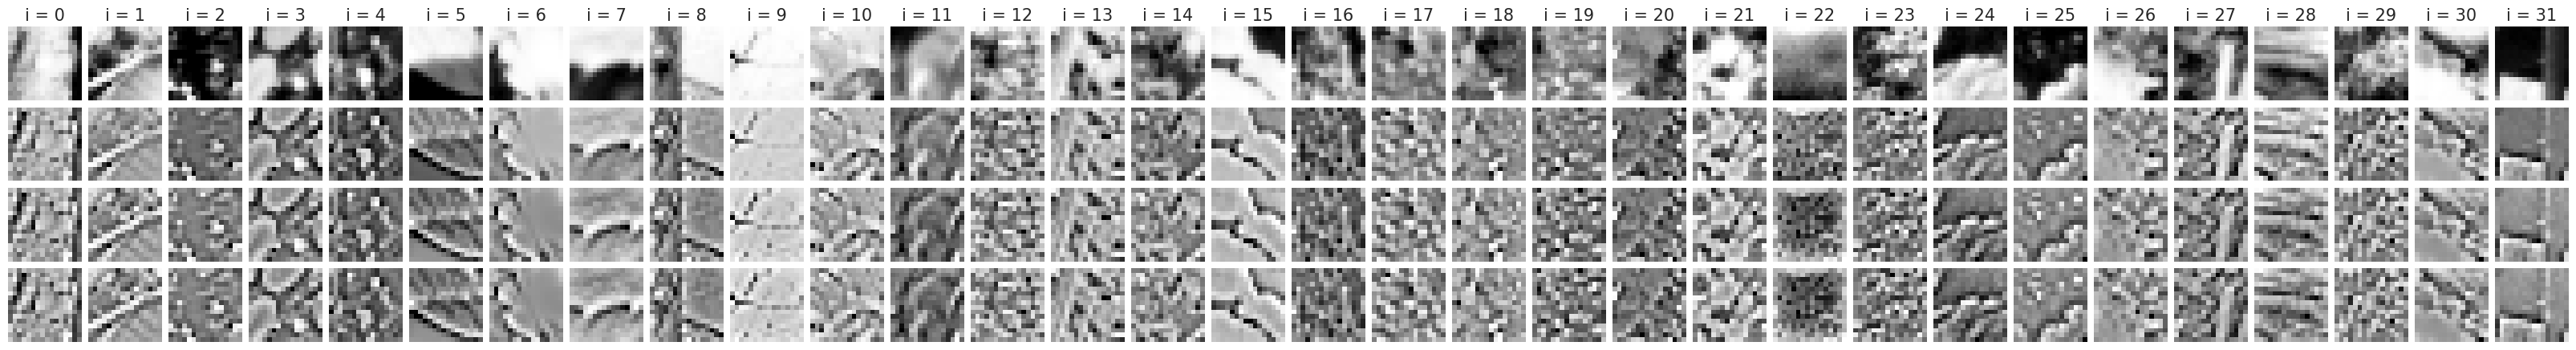

In [20]:
fig, axes = create_figure(4, ncols, (1.0 * ncols, 4.25), 'all', 'all')
for i in range(ncols):
    axes[0, i].imshow(tonp(x[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[1, i].imshow(tonp(x_wt[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[2, i].imshow(tonp(x_wt_cn[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[3, i].imshow(tonp(x_wt_cn_zs[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[0, i].set_title(f"i = {i}", fontsize=15)
remove_ticks(axes)
plt.show()

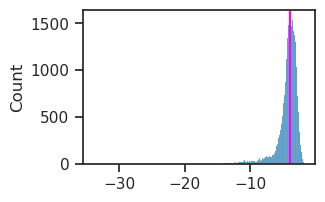

In [21]:
bad_i = 22

sns.histplot(log_vars)
plt.axvline(log_vars[ids[bad_i]], color='magenta');

## Save data

### Shuffle

In [22]:
shuffle_inds = np.arange(len(x))
rng = get_rng()
rng.shuffle(shuffle_inds)

### Create save dir

In [23]:
save_dir = pjoin(root, 'Kyoto16')
os.makedirs(save_dir, exist_ok=True)
os.listdir(save_dir)

['patches.npy', 'processed.npy', 'wt_cn.npy', 'wt.npy']

In [24]:
save_dir

'/home/hadi/Datasets/Kyoto/Kyoto16'

### Save

In [25]:
save = {
    'patches': tonp(x)[shuffle_inds],
    'wt': tonp(x_wt)[shuffle_inds],
    'wt_cn': tonp(x_wt_cn)[shuffle_inds],
    'processed': tonp(x_wt_cn_zs)[shuffle_inds],
}
for name, obj in save.items():
    save_obj(
        obj=obj,
        file_name=name,
        save_dir=save_dir,
        verbose=True,
        mode='npy',
    )

[PROGRESS] 'patches.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto16

[PROGRESS] 'wt.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto16

[PROGRESS] 'wt_cn.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto16

[PROGRESS] 'processed.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto16

## Xtract patches: $32 \times 32$

In [26]:
npix = 32
crop_size = 2

imgs_tensor = {
    k: torch.from_numpy(v.mean(-1)).to(device=device).unsqueeze(1)
    for k, v in imgs_color.items()
}

patches = {
    k: xtract_patches(v, npix=npix + 2 * crop_size)
    for k, v in imgs_tensor.items()
}
patches = torch.cat(list(patches.values()))
patches = patches.float()

print(patches.shape, patches.dtype)

torch.Size([62, 221, 1, 36, 36])
torch.float32

### Process

In [27]:
crop_size = 2

x_wt, x_wt_cn, x_wt_cn_zs = do_process(patches, crop_size=crop_size)
x = patches[..., crop_size:-crop_size, crop_size:-crop_size]

patches.shape, x_wt_cn_zs.shape

(torch.Size([62, 221, 1, 36, 36]), torch.Size([62, 221, 1, 32, 32]))

### Identify low contrast patches

Bottom 1%

In [28]:
q = 0.01

vars = np.var(tonp(x), axis=(-1, -2))
vars[vars == 0] = 1e-10  # prevent div by zero warning

log_vars = np.log(vars.ravel())
thres = np.quantile(log_vars, q)
accept = log_vars > thres

msg = f"# removed: {(~accept).sum()} ——— # final: {accept.sum()}"
print(msg)

# removed: 138 ——— # final: 13564

### Remove low contrast patches

In [29]:
x, x_wt, x_wt_cn, x_wt_cn_zs = map(
    lambda a: flatten_np(a, end_dim=1)[accept],
    [x, x_wt, x_wt_cn, x_wt_cn_zs],
)
x_wt_cn_zs.shape

torch.Size([13564, 1, 32, 32])

In [30]:
ncols = 32
rng = get_rng(0)
ids = rng.choice(range(len(x)), size=ncols, replace=False)

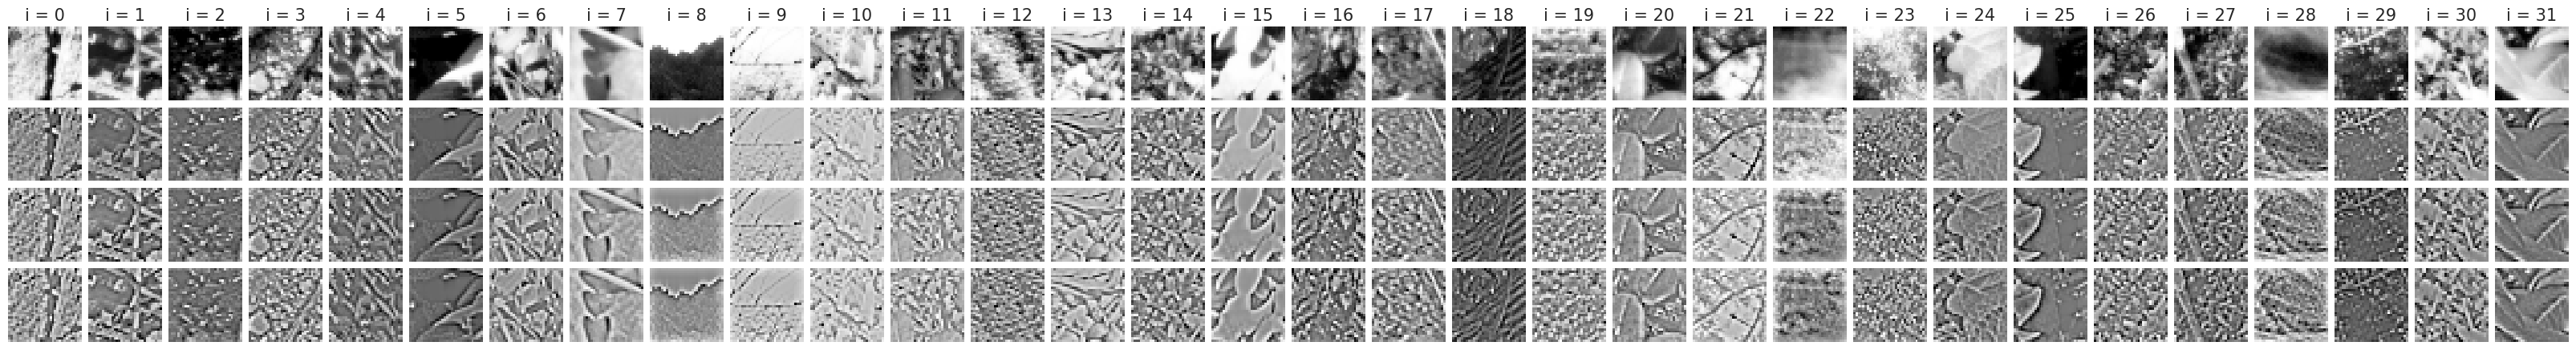

In [31]:
fig, axes = create_figure(4, ncols, (1.0 * ncols, 4.25), 'all', 'all')
for i in range(ncols):
    axes[0, i].imshow(tonp(x[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[1, i].imshow(tonp(x_wt[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[2, i].imshow(tonp(x_wt_cn[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[3, i].imshow(tonp(x_wt_cn_zs[ids[i], 0].squeeze()), cmap='Greys_r')
    axes[0, i].set_title(f"i = {i}", fontsize=15)
remove_ticks(axes)
plt.show()

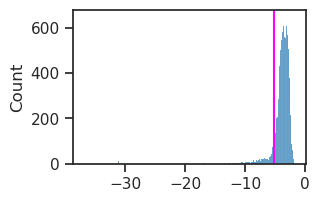

In [32]:
bad_i = 18

sns.histplot(log_vars)
plt.axvline(log_vars[ids[bad_i]], color='magenta');

## Save data

### Shuffle

In [33]:
shuffle_inds = np.arange(len(x))
rng = get_rng()
rng.shuffle(shuffle_inds)

### Create save dir

In [34]:
save_dir = pjoin(root, f'Kyoto{npix}')
os.makedirs(save_dir, exist_ok=True)
os.listdir(save_dir)

['patches.npy', 'processed.npy', 'wt_cn.npy', 'wt.npy']

In [35]:
save_dir

'/home/hadi/Datasets/Kyoto/Kyoto32'

### Save

In [36]:
save = {
    'patches': tonp(x)[shuffle_inds],
    'wt': tonp(x_wt)[shuffle_inds],
    'wt_cn': tonp(x_wt_cn)[shuffle_inds],
    'processed': tonp(x_wt_cn_zs)[shuffle_inds],
}
for name, obj in save.items():
    save_obj(
        obj=obj,
        file_name=name,
        save_dir=save_dir,
        verbose=True,
        mode='npy',
    )

[PROGRESS] 'patches.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto32

[PROGRESS] 'wt.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto32

[PROGRESS] 'wt_cn.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto32

[PROGRESS] 'processed.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto32